In [1]:
import os, json, shutil, zipfile, warnings
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import InceptionV3, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")


TensorFlow version : 2.19.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


In [3]:
ZIP_PATH     = '/content/drive/MyDrive/UECFOOD100.zip'  # ← EDIT IF NEEDED
EXTRACT_DIR  = '/content/UECFOOD100'
TRAIN_DIR    = '/content/food40/train'
VAL_DIR      = '/content/food40/val'
SAVE_DIR     = '/content/drive/MyDrive/FoodAI'          # output files here

IMG_SIZE         = 224     # works for both InceptionV3 and ResNet50
BATCH_SIZE       = 32
NUM_CLASSES      = 40      # first 40 UECFOOD100 classes
PHASE1_EPOCHS    = 15      # frozen-base phase
PHASE2_EPOCHS    = 20      # fine-tuning phase
FINE_TUNE_AT     = 40      # unfreeze last 40 layers of base model

os.makedirs(SAVE_DIR, exist_ok=True)
print("Config ready. Output will be saved to:", SAVE_DIR)

Config ready. Output will be saved to: /content/drive/MyDrive/FoodAI


In [4]:
if not os.path.exists(EXTRACT_DIR):
    print("Unzipping dataset (may take 2-5 minutes)...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('/content/')
    print("Done! Unzipped to:", EXTRACT_DIR)
else:
    print("Dataset already unzipped — skipping.")


Unzipping dataset (may take 2-5 minutes)...
Done! Unzipped to: /content/UECFOOD100


In [5]:
def find_class_root(base):
    """Walk the extracted folder tree to find where the
    numbered class directories (1, 2, 3 ...) actually live."""
    for root, dirs, _ in os.walk(base):
        numeric = [d for d in dirs if d.isdigit()]
        if len(numeric) >= 10:
            return root
    return base

DATASET_ROOT = find_class_root(EXTRACT_DIR)
print("Dataset root found at:", DATASET_ROOT)

# Sort class folder names by their integer value, pick first 40
all_numeric      = sorted([d for d in os.listdir(DATASET_ROOT) if d.isdigit()], key=int)
selected_folders = all_numeric[:NUM_CLASSES]
print(f"Selected {len(selected_folders)} class folders: {selected_folders}")


# ═══════════════════════════════════════════════════════════════

Dataset root found at: /content/UECFOOD100
Selected 40 class folders: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40']


In [6]:
category_txt   = os.path.join(EXTRACT_DIR, 'category.txt')
folder_to_name = {}

if os.path.exists(category_txt):
    with open(category_txt, encoding='utf-8', errors='ignore') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2 and parts[0].isdigit():
                # join multi-word names with underscore
                folder_to_name[parts[0]] = '_'.join(parts[1:])
    print(f"Loaded {len(folder_to_name)} category names.")
else:
    print("category.txt not found — will use folder numbers as class names.")

class_names = [folder_to_name.get(f, f'food_{f}') for f in selected_folders]
print("\nClass list:")
for i, (fld, name) in enumerate(zip(selected_folders, class_names)):
    print(f"  [{i:02d}] folder {fld:>3} → {name}")



Loaded 100 category names.

Class list:
  [00] folder   1 → rice
  [01] folder   2 → eels_on_rice
  [02] folder   3 → pilaf
  [03] folder   4 → chicken-'n'-egg_on_rice
  [04] folder   5 → pork_cutlet_on_rice
  [05] folder   6 → beef_curry
  [06] folder   7 → sushi
  [07] folder   8 → chicken_rice
  [08] folder   9 → fried_rice
  [09] folder  10 → tempura_bowl
  [10] folder  11 → bibimbap
  [11] folder  12 → toast
  [12] folder  13 → croissant
  [13] folder  14 → roll_bread
  [14] folder  15 → raisin_bread
  [15] folder  16 → chip_butty
  [16] folder  17 → hamburger
  [17] folder  18 → pizza
  [18] folder  19 → sandwiches
  [19] folder  20 → udon_noodle
  [20] folder  21 → tempura_udon
  [21] folder  22 → soba_noodle
  [22] folder  23 → ramen_noodle
  [23] folder  24 → beef_noodle
  [24] folder  25 → tensin_noodle
  [25] folder  26 → fried_noodle
  [26] folder  27 → spaghetti
  [27] folder  28 → Japanese-style_pancake
  [28] folder  29 → takoyaki
  [29] folder  30 → gratin
  [30] folder

In [7]:

if not os.path.exists(TRAIN_DIR):
    print("Building train/val folders...")
    os.makedirs(TRAIN_DIR)
    os.makedirs(VAL_DIR)

    for folder, name in zip(selected_folders, class_names):
        src = os.path.join(DATASET_ROOT, folder)
        if not os.path.isdir(src):
            print(f"  WARNING: {src} not found — skipping")
            continue

        # UECFOOD100 mixes images with .txt annotation files — keep only images
        imgs = [f for f in os.listdir(src)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        train_imgs, val_imgs = train_test_split(imgs, test_size=0.2, random_state=42)

        for split, split_list in [('train', train_imgs), ('val', val_imgs)]:
            dest = os.path.join('/content/food40', split, name)
            os.makedirs(dest, exist_ok=True)
            for img in split_list:
                shutil.copy2(os.path.join(src, img), os.path.join(dest, img))

        print(f"  {name}: {len(train_imgs)} train | {len(val_imgs)} val")

    print("Split complete!")
else:
    print("Train/val folders already exist — skipping copy.")

# Use folder names from train directory as the definitive class list
final_classes = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES   = len(final_classes)
print(f"\nFinal class count: {NUM_CLASSES}")


Building train/val folders...
  rice: 496 train | 124 val
  eels_on_rice: 104 train | 26 val
  pilaf: 92 train | 23 val
  chicken-'n'-egg_on_rice: 96 train | 25 val
  pork_cutlet_on_rice: 120 train | 30 val
  beef_curry: 196 train | 50 val
  sushi: 122 train | 31 val
  chicken_rice: 80 train | 20 val
  fried_rice: 135 train | 34 val
  tempura_bowl: 108 train | 28 val
  bibimbap: 89 train | 23 val
  toast: 174 train | 44 val
  croissant: 96 train | 24 val
  roll_bread: 85 train | 22 val
  raisin_bread: 80 train | 21 val
  chip_butty: 118 train | 30 val
  hamburger: 186 train | 47 val
  pizza: 107 train | 27 val
  sandwiches: 130 train | 33 val
  udon_noodle: 121 train | 31 val
  tempura_udon: 84 train | 22 val
  soba_noodle: 130 train | 33 val
  ramen_noodle: 282 train | 71 val
  beef_noodle: 111 train | 28 val
  tensin_noodle: 89 train | 23 val
  fried_noodle: 104 train | 27 val
  spaghetti: 120 train | 31 val
  Japanese-style_pancake: 109 train | 28 val
  takoyaki: 107 train | 27 val


In [8]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,        # normalize pixels to [0, 1]
    rotation_range=30,      # randomly rotate up to 30°
    zoom_range=0.25,        # randomly zoom in/out up to 25%
    width_shift_range=0.2,  # shift image left/right
    height_shift_range=0.2, # shift image up/down
    shear_range=0.2,        # apply shear transformation
    horizontal_flip=True,   # randomly mirror image
    fill_mode='nearest'     # fill empty pixels after transform
)

# Validation generator: only normalize, no augmentation
val_datagen = ImageDataGenerator(rescale=1.0/255)

train_flow = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_flow = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # keep order for evaluation
)

print(f"Training samples   : {train_flow.samples}")
print(f"Validation samples : {val_flow.samples}")
print(f"Classes            : {train_flow.num_classes}")



Found 5353 images belonging to 40 classes.
Found 1359 images belonging to 40 classes.
Training samples   : 5353
Validation samples : 1359
Classes            : 40


In [9]:
_BASE_CALORIES = {
    "rice":130, "eels_on_rice":165, "pilaf":180,
    "chicken_and_egg_on_rice":175, "pork_cutlet_on_rice":248,
    "beef_curry":150, "sushi":143, "chicken_rice":160,
    "fried_rice":185, "tempura":290, "bibimbap":120,
    "toast":265, "croissant":406, "roll_bread":280,
    "ramen_noodle":136, "takoyaki":165, "gratin":136,
    "sauteed_vegetables":70, "croquette":243, "hamburger":295,
    "pizza":266, "sandwiches":233, "udon_noodle":96,
    "pocky":476, "green_salad":15, "almond_jelly":95,
    "XO_sauce":156, "fried_egg":196, "minced_meat_fritters":250,
    "cream_puff":262, "waffles":291, "french_fries":312,
    "spring_rolls":185, "mixed_rice":140, "gnocchi":130,
    "macaroni_salad":165, "clam_chowder":80, "steak":271,
    "BBQ_beef":260, "cookie":480,
}

In [10]:
# Map calorie values to the actual class folder names we are using
calorie_dict = {}
for cls in final_classes:
    if cls in _BASE_CALORIES:
        calorie_dict[cls] = _BASE_CALORIES[cls]
    else:
        # fuzzy partial-name match
        matched = False
        for key, cal in _BASE_CALORIES.items():
            if key.lower() in cls.lower() or cls.lower() in key.lower():
                calorie_dict[cls] = cal
                matched = True
                break
        if not matched:
            calorie_dict[cls] = 200  # sensible default

print("Calorie dictionary built:")
for k, v in calorie_dict.items():
    print(f"  {k}: {v} kcal/100g")


Calorie dictionary built:
  Japanese-style_pancake: 200 kcal/100g
  beef_curry: 150 kcal/100g
  beef_noodle: 200 kcal/100g
  bibimbap: 120 kcal/100g
  chicken-'n'-egg_on_rice: 130 kcal/100g
  chicken_rice: 160 kcal/100g
  chip_butty: 200 kcal/100g
  croissant: 406 kcal/100g
  croquette: 243 kcal/100g
  eels_on_rice: 165 kcal/100g
  fried_noodle: 200 kcal/100g
  fried_rice: 185 kcal/100g
  gratin: 136 kcal/100g
  grilled_eggplant: 200 kcal/100g
  hamburger: 295 kcal/100g
  miso_soup: 200 kcal/100g
  oden: 200 kcal/100g
  omelet: 200 kcal/100g
  pilaf: 180 kcal/100g
  pizza: 266 kcal/100g
  pork_cutlet_on_rice: 248 kcal/100g
  potage: 200 kcal/100g
  raisin_bread: 200 kcal/100g
  ramen_noodle: 136 kcal/100g
  rice: 130 kcal/100g
  roll_bread: 280 kcal/100g
  sandwiches: 233 kcal/100g
  sausage: 200 kcal/100g
  sauteed_spinach: 200 kcal/100g
  sauteed_vegetables: 70 kcal/100g
  soba_noodle: 200 kcal/100g
  spaghetti: 200 kcal/100g
  sushi: 143 kcal/100g
  takoyaki: 165 kcal/100g
  tempura

In [11]:
def make_callbacks(save_path):
    """Standard callbacks used for every training run."""
    return [
        # Stop if val_accuracy doesn't improve for 8 consecutive epochs
        EarlyStopping(monitor='val_accuracy', patience=8,
                      restore_best_weights=True, verbose=1),
        # Save model only when val_accuracy improves
        ModelCheckpoint(save_path, monitor='val_accuracy',
                        save_best_only=True, verbose=1),
        # Reduce LR by 70% when val_loss is stuck for 4 epochs
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=4, min_lr=1e-7, verbose=1),
    ]


# ════════════════

In [12]:
def build_inceptionv3(num_classes, img_size):
    base = InceptionV3(weights='imagenet', include_top=False,
                       input_shape=(img_size, img_size, 3))
    base.trainable = False   # freeze for Phase 1

    inp = keras.Input(shape=(img_size, img_size, 3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(512, activation='relu')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inp, out, name='InceptionV3_Food'), base

iv3_model, iv3_base = build_inceptionv3(NUM_CLASSES, IMG_SIZE)
print("InceptionV3 ready. Params:", f"{iv3_model.count_params():,}")

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
InceptionV3 ready. Params: 22,995,528


In [13]:
def build_resnet50(num_classes, img_size):
    base = ResNet50(weights='imagenet', include_top=False,
                    input_shape=(img_size, img_size, 3))
    base.trainable = False

    inp = keras.Input(shape=(img_size, img_size, 3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(512, activation='relu')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inp, out, name='ResNet50_Food'), base

res_model, res_base = build_resnet50(NUM_CLASSES, IMG_SIZE)
print("ResNet50 ready. Params:", f"{res_model.count_params():,}")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 ready. Params: 24,780,456


In [14]:
print("\n" + "="*55)
print("  PHASE 1 — InceptionV3 (base frozen)")
print("="*55)
iv3_model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy',
                  metrics=['accuracy'])
h_iv3_p1 = iv3_model.fit(
    train_flow, validation_data=val_flow,
    epochs=PHASE1_EPOCHS,
    callbacks=make_callbacks('/content/iv3_p1_best.h5'), verbose=1
)
print(f"  Best Phase-1 val_accuracy (IV3): {max(h_iv3_p1.history['val_accuracy']):.4f}")

print("\n" + "="*55)
print("  PHASE 1 — ResNet50 (base frozen)")
print("="*55)
res_model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy',
                  metrics=['accuracy'])
h_res_p1 = res_model.fit(
    train_flow, validation_data=val_flow,
    epochs=PHASE1_EPOCHS,
    callbacks=make_callbacks('/content/res_p1_best.h5'), verbose=1
)
print(f"  Best Phase-1 val_accuracy (RN50): {max(h_res_p1.history['val_accuracy']):.4f}")



  PHASE 1 — InceptionV3 (base frozen)
Epoch 1/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.2670 - loss: 2.9545
Epoch 1: val_accuracy improved from None to 0.51950, saving model to /content/iv3_p1_best.h5



Epoch 1: finished saving model to /content/iv3_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 129s 657ms/step - accuracy: 0.3568 - loss: 2.4065 - val_accuracy: 0.5195 - val_loss: 1.6899 - learning_rate: 0.0010
Epoch 2/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.4944 - loss: 1.7256
Epoch 2: val_accuracy improved from 0.51950 to 0.56954, saving model to /content/iv3_p1_best.h5



Epoch 2: finished saving model to /content/iv3_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 83s 493ms/step - accuracy: 0.4950 - loss: 1.7310 - val_accuracy: 0.5695 - val_loss: 1.4491 - learning_rate: 0.0010
Epoch 3/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.5364 - loss: 1.5676
Epoch 3: val_accuracy did not improve from 0.56954
168/168 ━━━━━━━━━━━━━━━━━━━━ 82s 488ms/step - accuracy: 0.5333 - loss: 1.5721 - val_accuracy: 0.5695 - val_loss: 1.3446 - learning_rate: 0.0010
Epoch 4/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.5645 - loss: 1.4396
Epoch 4: val_accuracy improved from 0.56954 to 0.58940, saving model to /content/iv3_p1_best.h5



Epoch 4: finished saving model to /content/iv3_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 84s 499ms/step - accuracy: 0.5580 - loss: 1.4674 - val_accuracy: 0.5894 - val_loss: 1.2830 - learning_rate: 0.0010
Epoch 5/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.5843 - loss: 1.3236
Epoch 5: val_accuracy did not improve from 0.58940
168/168 ━━━━━━━━━━━━━━━━━━━━ 83s 494ms/step - accuracy: 0.5862 - loss: 1.3525 - val_accuracy: 0.5879 - val_loss: 1.3326 - learning_rate: 0.0010
Epoch 6/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.5976 - loss: 1.3143
Epoch 6: val_accuracy improved from 0.58940 to 0.60338, saving model to /content/iv3_p1_best.h5



Epoch 6: finished saving model to /content/iv3_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 83s 493ms/step - accuracy: 0.5914 - loss: 1.3236 - val_accuracy: 0.6034 - val_loss: 1.2578 - learning_rate: 0.0010
Epoch 7/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.6033 - loss: 1.2879
Epoch 7: val_accuracy improved from 0.60338 to 0.61001, saving model to /content/iv3_p1_best.h5


...


Epoch 1: finished saving model to /content/res_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 124s 636ms/step - accuracy: 0.0996 - loss: 3.6381 - val_accuracy: 0.1074 - val_loss: 3.5606 - learning_rate: 0.0010
Epoch 2/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.1351 - loss: 3.4087
Epoch 2: val_accuracy improved from 0.10743 to 0.11185, saving model to /content/res_p1_best.h5



Epoch 2: finished saving model to /content/res_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 92s 546ms/step - accuracy: 0.1296 - loss: 3.4010 - val_accuracy: 0.1118 - val_loss: 3.8973 - learning_rate: 0.0010
Epoch 3/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.1402 - loss: 3.2923
Epoch 3: val_accuracy improved from 0.11185 to 0.12141, saving model to /content/res_p1_best.h5



Epoch 3: finished saving model to /content/res_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 92s 547ms/step - accuracy: 0.1364 - loss: 3.2951 - val_accuracy: 0.1214 - val_loss: 3.3882 - learning_rate: 0.0010
Epoch 4/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.1432 - loss: 3.2732
Epoch 4: val_accuracy improved from 0.12141 to 0.14790, saving model to /content/res_p1_best.h5



Epoch 4: finished saving model to /content/res_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 91s 542ms/step - accuracy: 0.1459 - loss: 3.2579 - val_accuracy: 0.1479 - val_loss: 3.6537 - learning_rate: 0.0010
Epoch 5/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.1490 - loss: 3.1866
Epoch 5: val_accuracy did not improve from 0.14790
168/168 ━━━━━━━━━━━━━━━━━━━━ 91s 542ms/step - accuracy: 0.1534 - loss: 3.1989 - val_accuracy: 0.0596 - val_loss: 4.6573 - learning_rate: 0.0010
Epoch 6/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.1648 - loss: 3.1703
Epoch 6: val_accuracy did not improve from 0.14790
168/168 ━━━━━━━━━━━━━━━━━━━━ 92s 545ms/step - accuracy: 0.1575 - loss: 3.1768 - val_accuracy: 0.0824 - val_loss: 3.9542 - learning_rate: 0.0010
Epoch 7/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.1531 - loss: 3.1712
Epoch 7: val_accuracy did not improve from 0.14790

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
168/168 ━━━━━━━


Epoch 8: finished saving model to /content/res_p1_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 93s 553ms/step - accuracy: 0.1685 - loss: 3.1060 - val_accuracy: 0.1979 - val_loss: 3.0065 - learning_rate: 3.0000e-04
Epoch 9/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.1741 - loss: 3.0812
Epoch 9: val_accuracy did not improve from 0.19794
168/168 ━━━━━━━━━━━━━━━━━━━━ 94s 558ms/step - accuracy: 0.1745 - loss: 3.0809 - val_accuracy: 0.1943 - val_loss: 2.9950 - learning_rate: 3.0000e-04
Epoch 10/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.1822 - loss: 3.0715
Epoch 10: val_accuracy did not improve from 0.19794
168/168 ━━━━━━━━━━━━━━━━━━━━ 89s 528ms/step - accuracy: 0.1844 - loss: 3.0621 - val_accuracy: 0.1464 - val_loss: 3.4729 - learning_rate: 3.0000e-04
Epoch 11/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.1724 - loss: 3.0351
Epoch 11: val_accuracy did not improve from 0.19794
168/168 ━━━━━━━━━━━━━━━━━━━━ 85s 508ms/step - accuracy: 0.1758 - loss: 3.033

In [15]:
def fine_tune(model, base, fine_tune_at):
    """Unfreeze the last fine_tune_at layers and recompile with tiny LR."""
    base.trainable = True
    freeze_until = len(base.layers) - fine_tune_at
    for i, layer in enumerate(base.layers):
        layer.trainable = (i >= freeze_until)
    unfrozen = sum(1 for l in base.layers if l.trainable)
    print(f"  Base layers: {len(base.layers)} total | {unfrozen} unfrozen")
    model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("\n" + "="*55)
print("  PHASE 2 — InceptionV3 fine-tuning")
print("="*55)
iv3_model = fine_tune(iv3_model, iv3_base, FINE_TUNE_AT)
h_iv3_p2  = iv3_model.fit(
    train_flow, validation_data=val_flow,
    epochs=PHASE2_EPOCHS,
    callbacks=make_callbacks('/content/iv3_final_best.h5'), verbose=1
)
print(f"  Best Phase-2 val_accuracy (IV3): {max(h_iv3_p2.history['val_accuracy']):.4f}")

print("\n" + "="*55)
print("  PHASE 2 — ResNet50 fine-tuning")
print("="*55)
res_model = fine_tune(res_model, res_base, FINE_TUNE_AT)
h_res_p2  = res_model.fit(
    train_flow, validation_data=val_flow,
    epochs=PHASE2_EPOCHS,
    callbacks=make_callbacks('/content/res_final_best.h5'), verbose=1
)
print(f"  Best Phase-2 val_accuracy (RN50): {max(h_res_p2.history['val_accuracy']):.4f}")




  PHASE 2 — InceptionV3 fine-tuning
  Base layers: 311 total | 40 unfrozen
Epoch 1/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.6296 - loss: 1.2001
Epoch 1: val_accuracy improved from None to 0.64827, saving model to /content/iv3_final_best.h5



Epoch 1: finished saving model to /content/iv3_final_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 127s 612ms/step - accuracy: 0.6273 - loss: 1.1953 - val_accuracy: 0.6483 - val_loss: 1.1078 - learning_rate: 1.0000e-05
Epoch 2/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.6512 - loss: 1.1134
Epoch 2: val_accuracy improved from 0.64827 to 0.65269, saving model to /content/iv3_final_best.h5



Epoch 2: finished saving model to /content/iv3_final_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 84s 499ms/step - accuracy: 0.6579 - loss: 1.0903 - val_accuracy: 0.6527 - val_loss: 1.0993 - learning_rate: 1.0000e-05
Epoch 3/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.6415 - loss: 1.1195
Epoch 3: val_accuracy improved from 0.65269 to 0.65563, saving model to /content/iv3_final_best.h5



Epoch 3: finished saving model to /content/iv3_final_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 83s 493ms/step - accuracy: 0.6499 - loss: 1.0928 - val_accuracy: 0.6556 - val_loss: 1.0822 - learning_rate: 1.0000e-05
Epoch 4/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.6700 - loss: 1.0409
Epoch 4: val_accuracy did not improve from 0.65563
168/168 ━━━━━━━━━━━━━━━━━━━━ 81s 480ms/step - accuracy: 0.6690 - loss: 1.0345 - val_accuracy: 0.6512 - val_loss: 1.0785 - learning_rate: 1.0000e-05
Epoch 5/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.6816 - loss: 0.9941
Epoch 5: val_accuracy improved from 0.65563 to 0.66152, saving model to /content/iv3_final_best.h5



Epoch 5: finished saving model to /content/iv3_final_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 84s 496ms/step - accuracy: 0.6817 - loss: 0.9991 - val_accuracy: 0.6615 - val_loss: 1.0722 - learning_rate: 1.0000e-05
Epoch 6/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.6935 - loss: 0.9755
Epoch 6: val_accuracy did not improve from 0.66152
168/168 ━━━━━━━━━━━━━━━━━━━━ 83s 492ms/step - accuracy: 0.6834 - loss: 1.0020 - val_accuracy: 0.6600 - val_loss: 1.0626 - learning_rate: 1.0000e-05
Epoch 7/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.6935 - loss: 0.9564
Epoch 7: val_accuracy did not improve from 0.66152
168/168 ━━━━━━━━━━━━━━━━━━━━ 82s 491ms/step - accuracy: 0.6981 - loss: 0.9382 - val_accuracy: 0.6549 - val_loss: 1.0533 - learning_rate: 1.0000e-05
Epoch 8/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.7024 - loss: 0.9151
Epoch 8: val_accuracy did not improve from 0.66152
168/168 ━━━━━━━━━━━━━━━━━━━━ 82s 490ms/step - accuracy: 0.6998 - loss: 0.9256

...


Epoch 10: finished saving model to /content/res_final_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 89s 531ms/step - accuracy: 0.1803 - loss: 3.0638 - val_accuracy: 0.2009 - val_loss: 2.9856 - learning_rate: 1.0000e-05
Epoch 11/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.1686 - loss: 3.0508
Epoch 11: val_accuracy did not improve from 0.20088
168/168 ━━━━━━━━━━━━━━━━━━━━ 88s 525ms/step - accuracy: 0.1722 - loss: 3.0434 - val_accuracy: 0.2009 - val_loss: 2.9973 - learning_rate: 1.0000e-05
Epoch 12/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.1839 - loss: 3.0309
Epoch 12: val_accuracy improved from 0.20088 to 0.22664, saving model to /content/res_final_best.h5



Epoch 12: finished saving model to /content/res_final_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 90s 537ms/step - accuracy: 0.1844 - loss: 3.0330 - val_accuracy: 0.2266 - val_loss: 2.8431 - learning_rate: 1.0000e-05
Epoch 13/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.1888 - loss: 3.0047
Epoch 13: val_accuracy did not improve from 0.22664
168/168 ━━━━━━━━━━━━━━━━━━━━ 86s 511ms/step - accuracy: 0.1834 - loss: 3.0463 - val_accuracy: 0.2009 - val_loss: 2.8993 - learning_rate: 1.0000e-05
Epoch 14/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.1884 - loss: 3.0353
Epoch 14: val_accuracy did not improve from 0.22664
168/168 ━━━━━━━━━━━━━━━━━━━━ 143s 519ms/step - accuracy: 0.1872 - loss: 3.0338 - val_accuracy: 0.1913 - val_loss: 3.1299 - learning_rate: 1.0000e-05
Epoch 15/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.1878 - loss: 3.0180
Epoch 15: val_accuracy did not improve from 0.22664
168/168 ━━━━━━━━━━━━━━━━━━━━ 87s 517ms/step - accuracy: 0.1928 - loss


Epoch 17: finished saving model to /content/res_final_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 87s 521ms/step - accuracy: 0.1930 - loss: 2.9672 - val_accuracy: 0.2414 - val_loss: 2.8101 - learning_rate: 3.0000e-06
Epoch 18/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.1928 - loss: 2.9628
Epoch 18: val_accuracy improved from 0.24135 to 0.24356, saving model to /content/res_final_best.h5



Epoch 18: finished saving model to /content/res_final_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 89s 530ms/step - accuracy: 0.1982 - loss: 2.9567 - val_accuracy: 0.2436 - val_loss: 2.8037 - learning_rate: 3.0000e-06
Epoch 19/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.2074 - loss: 2.9133
Epoch 19: val_accuracy improved from 0.24356 to 0.24503, saving model to /content/res_final_best.h5



Epoch 19: finished saving model to /content/res_final_best.h5
168/168 ━━━━━━━━━━━━━━━━━━━━ 94s 556ms/step - accuracy: 0.1965 - loss: 2.9408 - val_accuracy: 0.2450 - val_loss: 2.7990 - learning_rate: 3.0000e-06
Epoch 20/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.2233 - loss: 2.8995
Epoch 20: val_accuracy did not improve from 0.24503
168/168 ━━━━━━━━━━━━━━━━━━━━ 88s 525ms/step - accuracy: 0.2133 - loss: 2.9210 - val_accuracy: 0.2362 - val_loss: 2.7910 - learning_rate: 3.0000e-06
Restoring model weights from the end of the best epoch: 19.
  Best Phase-2 val_accuracy (RN50): 0.2450


In [16]:
best_iv3 = keras.models.load_model('/content/iv3_final_best.h5')
best_res  = keras.models.load_model('/content/res_final_best.h5')

val_flow.reset(); iv3_loss, iv3_acc = best_iv3.evaluate(val_flow, verbose=0)
val_flow.reset(); res_loss, res_acc = best_res.evaluate(val_flow,  verbose=0)

print(f"\n  InceptionV3  → {iv3_acc*100:.2f}%  (loss {iv3_loss:.4f})")
print(f"  ResNet50     → {res_acc*100:.2f}%  (loss {res_loss:.4f})")

if iv3_acc >= res_acc:
    best_model, best_name, best_acc = best_iv3, "InceptionV3", iv3_acc
else:
    best_model, best_name, best_acc = best_res,  "ResNet50",    res_acc
print(f"\n  Winner: {best_name} ({best_acc*100:.2f}%)")


  InceptionV3  → 68.14%  (loss 1.0037)
  ResNet50     → 24.50%  (loss 2.7990)

  Winner: InceptionV3 (68.14%)


In [17]:
best_model.save(os.path.join(SAVE_DIR, 'food_model.h5'))
print("Saved food_model.h5")

with open(os.path.join(SAVE_DIR, 'class_names.json'), 'w') as f:
    json.dump(final_classes, f, indent=2)
print("Saved class_names.json")

with open(os.path.join(SAVE_DIR, 'calorie_dict.json'), 'w') as f:
    json.dump(calorie_dict, f, indent=2)
print("Saved calorie_dict.json")

with open(os.path.join(SAVE_DIR, 'model_info.json'), 'w') as f:
    json.dump({"winner": best_name,
               "inceptionv3_acc": round(float(iv3_acc), 4),
               "resnet50_acc":    round(float(res_acc),  4)}, f, indent=2)
print("Saved model_info.json")

Saved food_model.h5
Saved class_names.json
Saved calorie_dict.json
Saved model_info.json


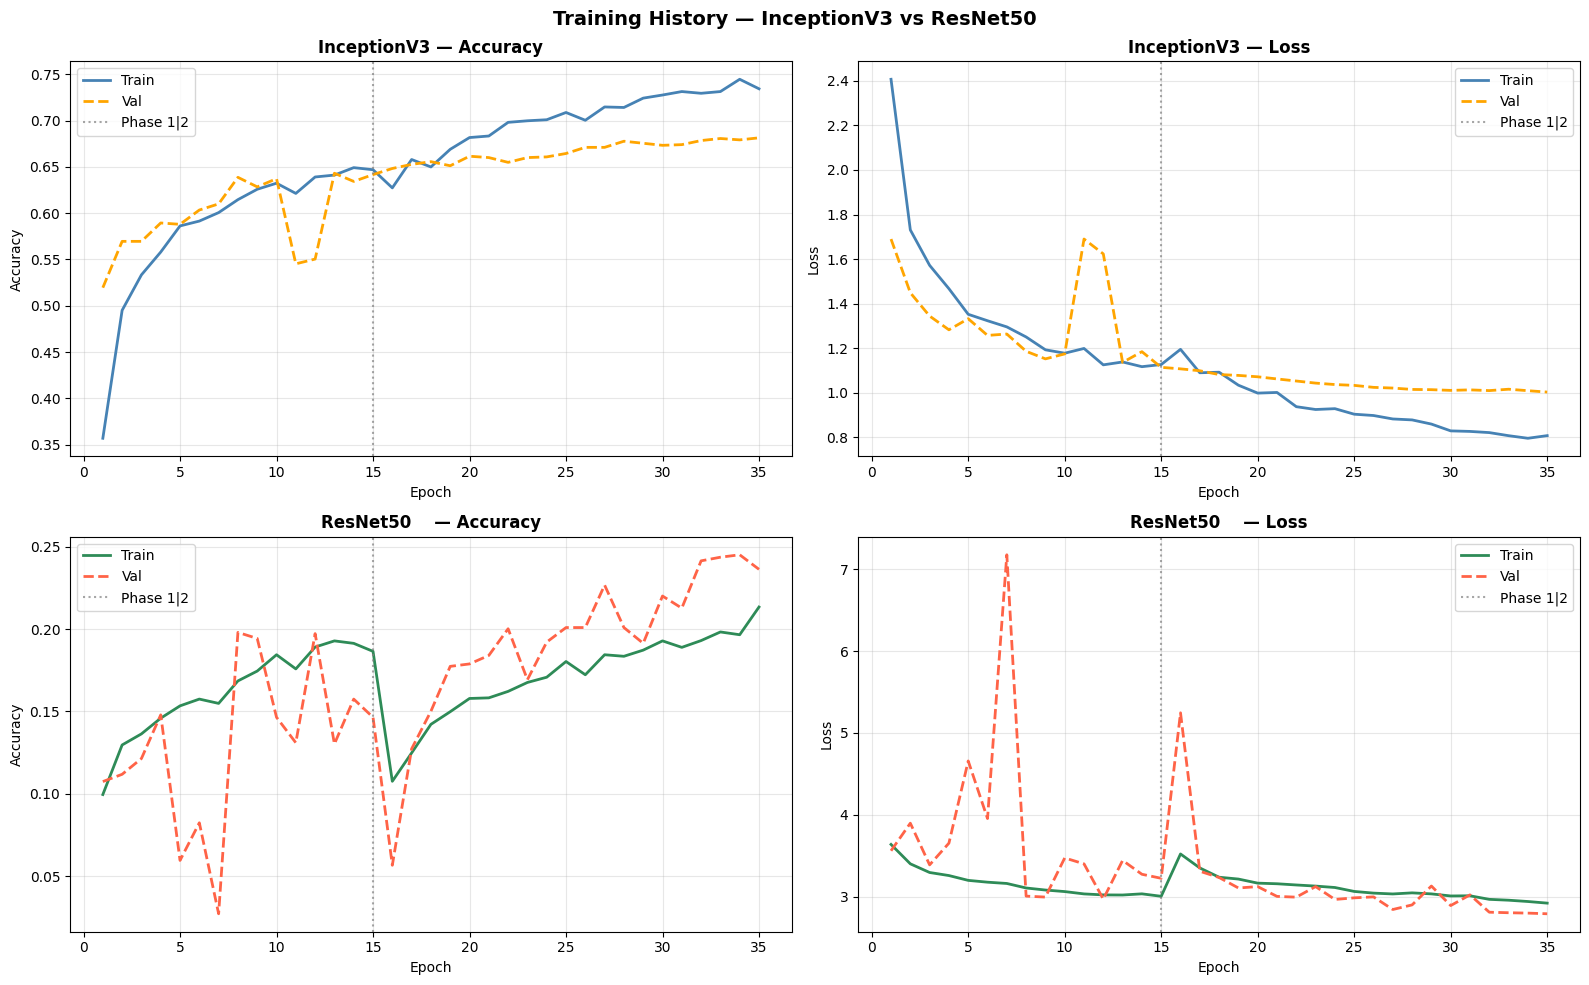

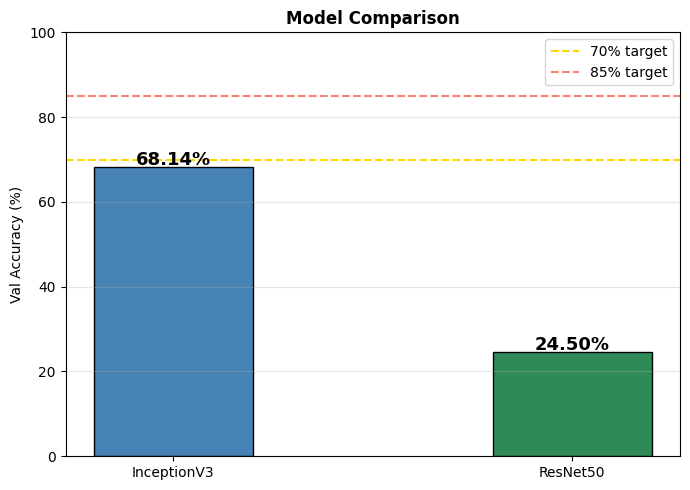

In [18]:

def concat(h1, h2):
    return {k: h1.history[k] + h2.history[k] for k in h1.history}

iv3_hist = concat(h_iv3_p1, h_iv3_p2)
res_hist = concat(h_res_p1, h_res_p2)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training History — InceptionV3 vs ResNet50',
             fontsize=14, fontweight='bold')

for ax, hist, title, colors in [
    (axes[0,0], iv3_hist, 'InceptionV3 — Accuracy', ('steelblue','orange')),
    (axes[0,1], iv3_hist, 'InceptionV3 — Loss',     ('steelblue','orange')),
    (axes[1,0], res_hist, 'ResNet50    — Accuracy',  ('seagreen','tomato')),
    (axes[1,1], res_hist, 'ResNet50    — Loss',      ('seagreen','tomato')),
]:
    metric = 'accuracy' if 'Accuracy' in title else 'loss'
    ep = range(1, len(hist[metric])+1)
    ax.plot(ep, hist[metric],          color=colors[0], lw=2, label='Train')
    ax.plot(ep, hist[f'val_{metric}'], color=colors[1], lw=2,
            linestyle='--', label='Val')
    ax.axvline(PHASE1_EPOCHS, color='gray', linestyle=':', alpha=0.7,
               label='Phase 1|2')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(metric.capitalize())
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Comparison bar chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['InceptionV3','ResNet50'], [iv3_acc*100, res_acc*100],
              color=['steelblue','seagreen'], width=0.4, edgecolor='black')
for bar, acc in zip(bars, [iv3_acc*100, res_acc*100]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=13)
ax.axhline(70, color='gold',   linestyle='--', label='70% target')
ax.axhline(85, color='salmon', linestyle='--', label='85% target')
ax.set_ylim(0, 100); ax.set_ylabel('Val Accuracy (%)');
ax.set_title('Model Comparison', fontweight='bold')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'comparison_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

In [19]:
val_flow.reset()
y_pred = np.argmax(best_model.predict(val_flow, verbose=1), axis=1)
y_true = val_flow.classes
print(classification_report(y_true, y_pred, target_names=final_classes, zero_division=0))


43/43 ━━━━━━━━━━━━━━━━━━━━ 22s 274ms/step
                         precision    recall  f1-score   support

 Japanese-style_pancake       0.91      0.75      0.82        28
             beef_curry       0.77      0.72      0.74        50
            beef_noodle       0.58      0.50      0.54        28
               bibimbap       0.89      0.74      0.81        23
chicken-'n'-egg_on_rice       0.59      0.80      0.68        25
           chicken_rice       0.44      0.35      0.39        20
             chip_butty       0.67      0.53      0.59        30
              croissant       0.91      0.83      0.87        24
              croquette       0.77      0.65      0.71        26
           eels_on_rice       0.96      1.00      0.98        26
           fried_noodle       0.74      0.63      0.68        27
             fried_rice       0.51      0.65      0.57        34
                 gratin       0.74      0.61      0.67        23
       grilled_eggplant       0.50      0.52   

In [20]:
print("\n" + "="*55)
print(f"  TRAINING COMPLETE  |  {best_name}  {best_acc*100:.2f}%")
print("="*55)
print(f"  Files saved in:  {SAVE_DIR}")
print()
print("  ► Download to your Windows PC:")
print("      food_model.h5")
print("      class_names.json")
print("      calorie_dict.json")
print()
print("  ► Then on Windows, run the Streamlit app:")
print("      pip install -r requirements.txt")
print("      streamlit run app.py")



  TRAINING COMPLETE  |  InceptionV3  68.14%
  Files saved in:  /content/drive/MyDrive/FoodAI

  ► Download to your Windows PC:
      food_model.h5
      class_names.json
      calorie_dict.json

  ► Then on Windows, run the Streamlit app:
      pip install -r requirements.txt
      streamlit run app.py
